In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Python dataset/Titanic-Dataset.csv")

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.shape

(891, 12)

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
df["Survival Status"] = df["Survived"].map({0: "Dead", 1: "Alive"})

In [25]:
# Survival count
print(df["Survival Status"].value_counts())

Survival Status
Dead     549
Alive    342
Name: count, dtype: int64


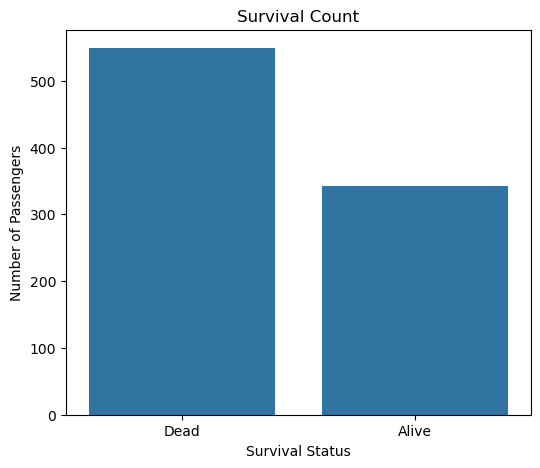

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(x="Survival Status", data=df)

plt.title("Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

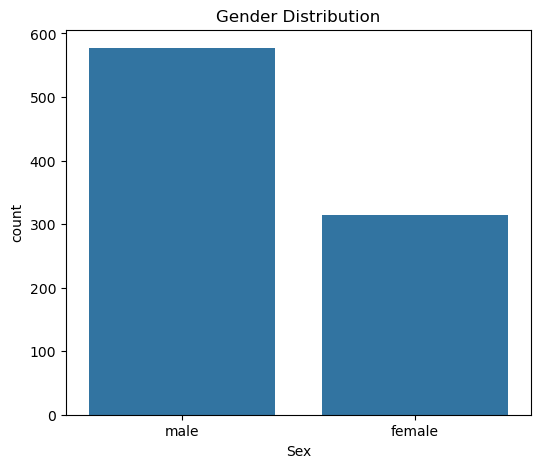

In [19]:
# Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.show()


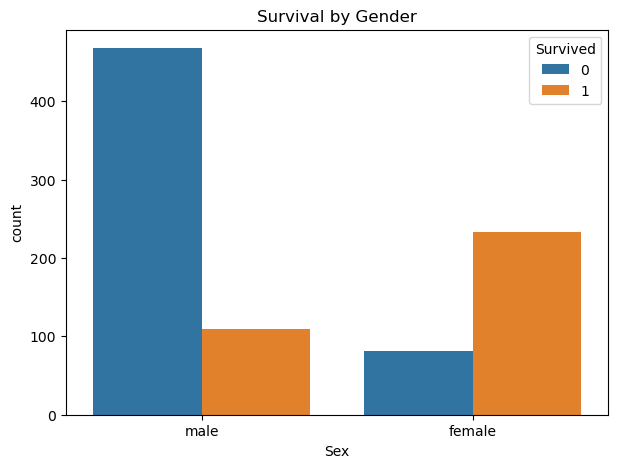

In [20]:
# Survial by gender

plt.figure(figsize=(7,5))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Survival by Gender")

plt.show()

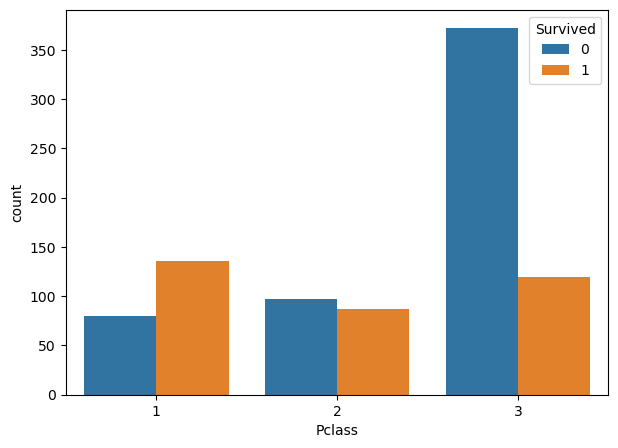

In [26]:
# Age Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.show()


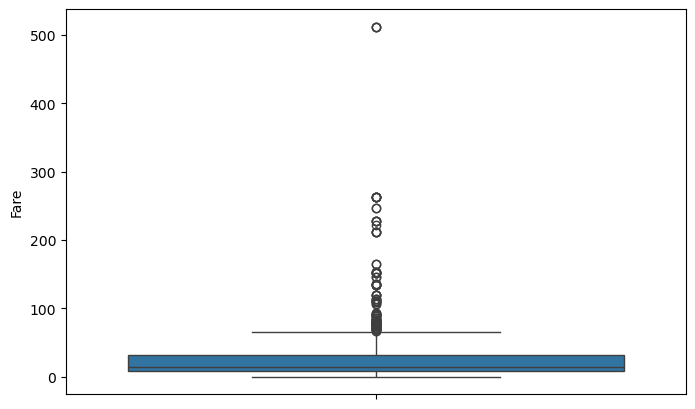

In [27]:
# Box plot
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Fare"]
)

plt.show()

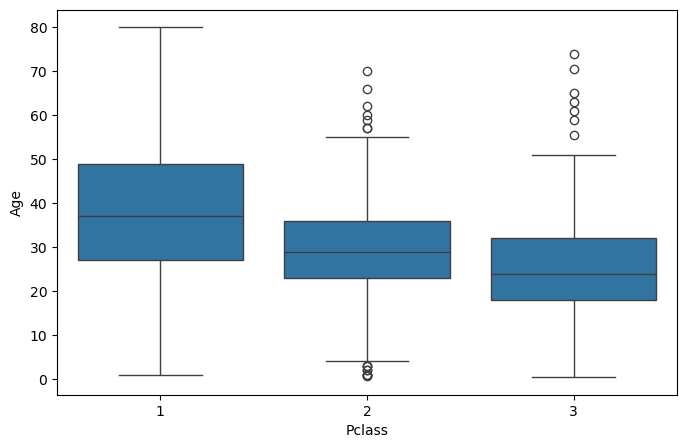

In [28]:
# Age by passenger class
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Pclass",
    y="Age",
    data=df
)

plt.show()

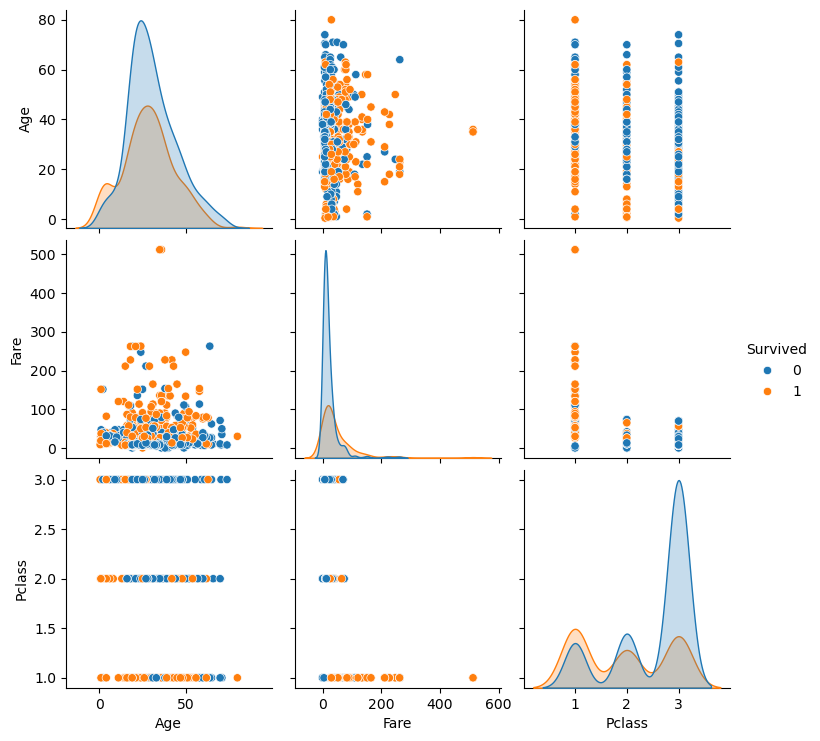

In [29]:
# Pairplot
sns.pairplot(
    df[
        ["Age",
         "Fare",
         "Pclass",
         "Survived"]
    ],
    hue="Survived"
)

plt.show()

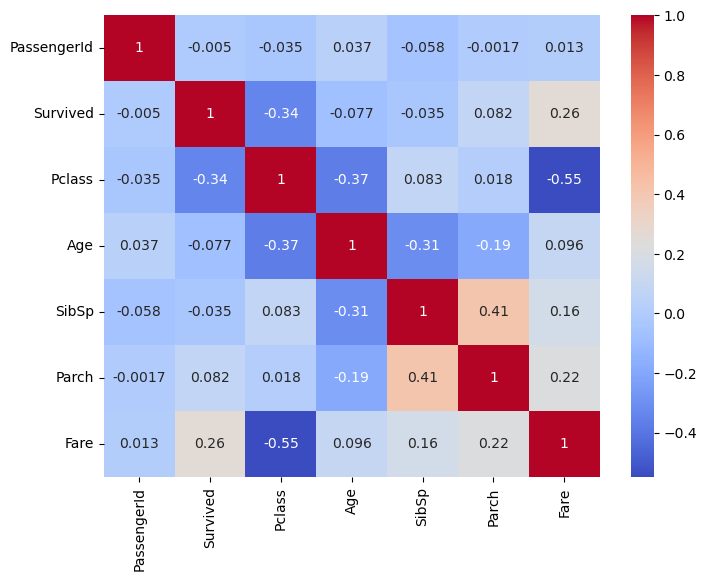

In [30]:
# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [31]:
# Survival Rate by Gender
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

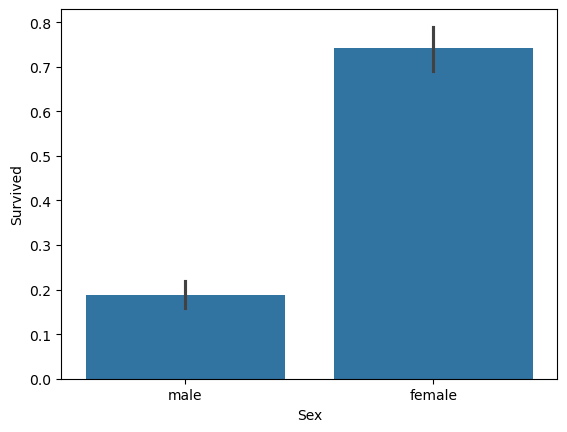

In [32]:
sns.barplot(
    x="Sex",
    y="Survived",
    data=df
)

plt.show()

In [33]:
# survial percentage
survival_rate = df["Survived"].mean()*100

print("Survival Percentage =", survival_rate)

Survival Percentage = 38.38383838383838


In [34]:
df.groupby("Pclass").mean(numeric_only=True)

,PassengerId,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,,
1,461.597222,0.629630,38.233441,0.416667,0.356481,84.154687
2,445.956522,0.472826,29.877630,0.402174,0.380435,20.662183
3,439.154786,0.242363,25.140620,0.615071,0.393075,13.675550


In [35]:
df.groupby("Sex").mean(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
Sex,,,,,,,
female,431.028662,0.742038,2.159236,27.915709,0.694268,0.649682,44.479818
male,454.147314,0.188908,2.389948,30.726645,0.429809,0.235702,25.523893
